Missing Values:
 id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

Summary Statistics:
                 id  absence_days  weekly_self_study_hours   math_score  \
count  2000.000000   2000.000000              2000.000000  2000.000000   
mean   1000.500000      3.665500                17.755500    83.452000   
std     577.494589      2.629271                12.129604    13.224906   
min       1.000000      0.000000                 0.000000    40.000000   
25%     500.750000      2.000000  

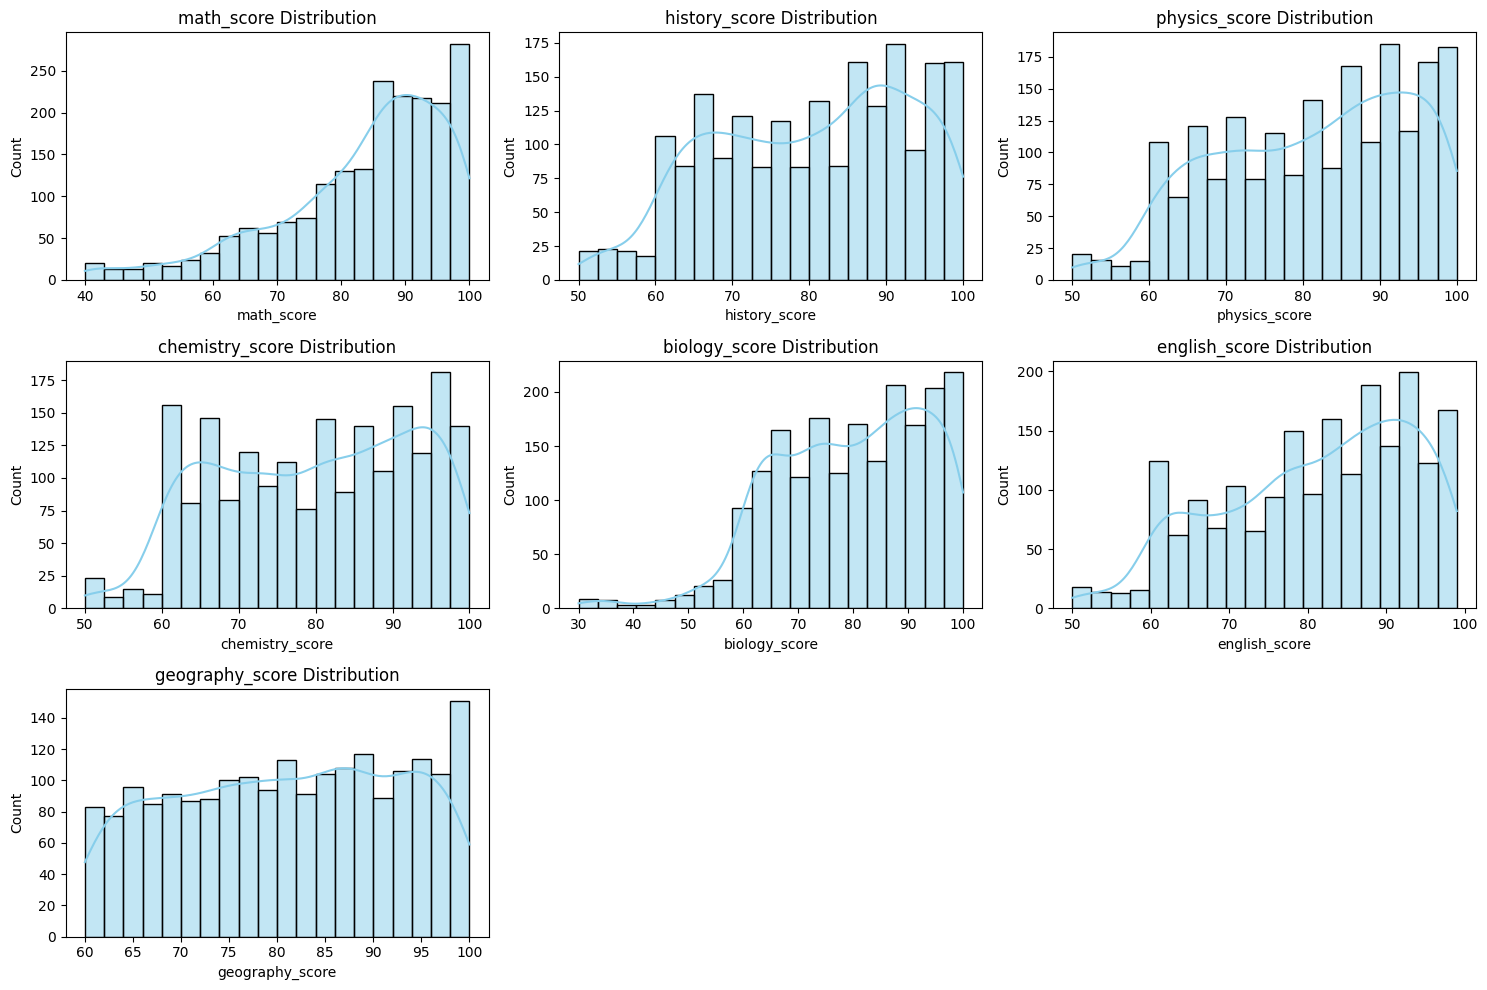

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('student-scores.csv')

### STEP 1: Data Summary & Quality Check
print("Missing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

### STEP 2: Score Distributions
score_columns = ['math_score', 'history_score', 'physics_score',
                 'chemistry_score', 'biology_score', 'english_score', 'geography_score']

plt.figure(figsize=(15, 10))
for i, col in enumerate(score_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

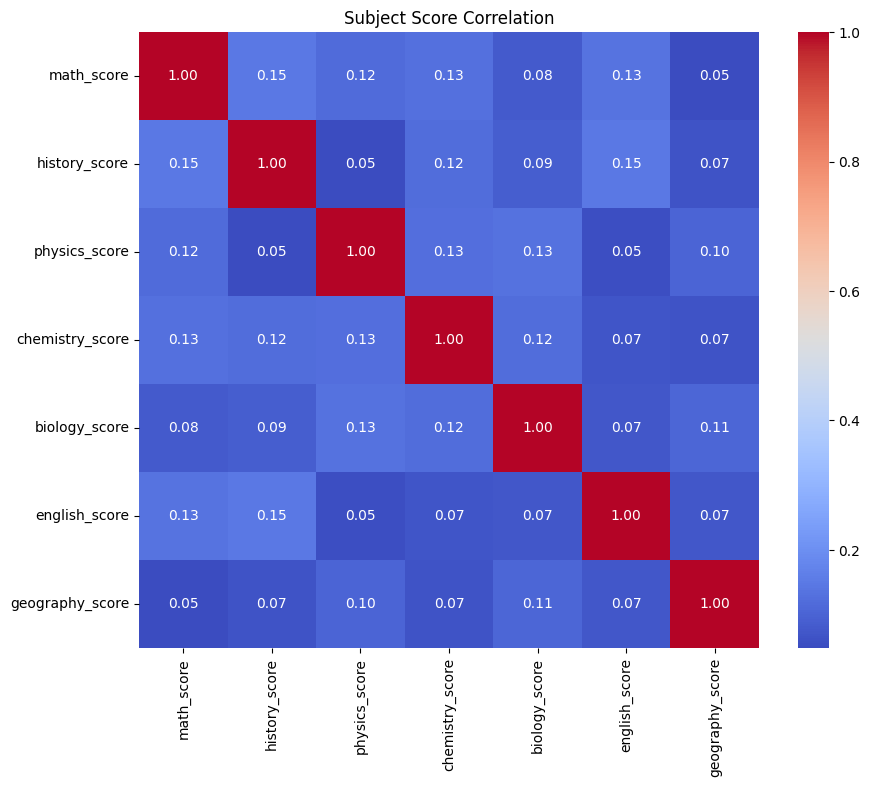

In [11]:
### STEP 3: Correlation Heatmap Between Subjects
plt.figure(figsize=(10, 8))
corr = df[score_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Subject Score Correlation")
plt.show()



Average Scores by Gender:
         math_score  history_score  physics_score  chemistry_score  \
gender                                                              
female   82.792415      80.495010      80.678643        80.382236   
male     84.114228      80.168337      81.996994        79.606212   

        biology_score  english_score  geography_score  
gender                                                 
female      79.216567      81.740519        80.953094  
male        79.947896      80.812625        80.822645  


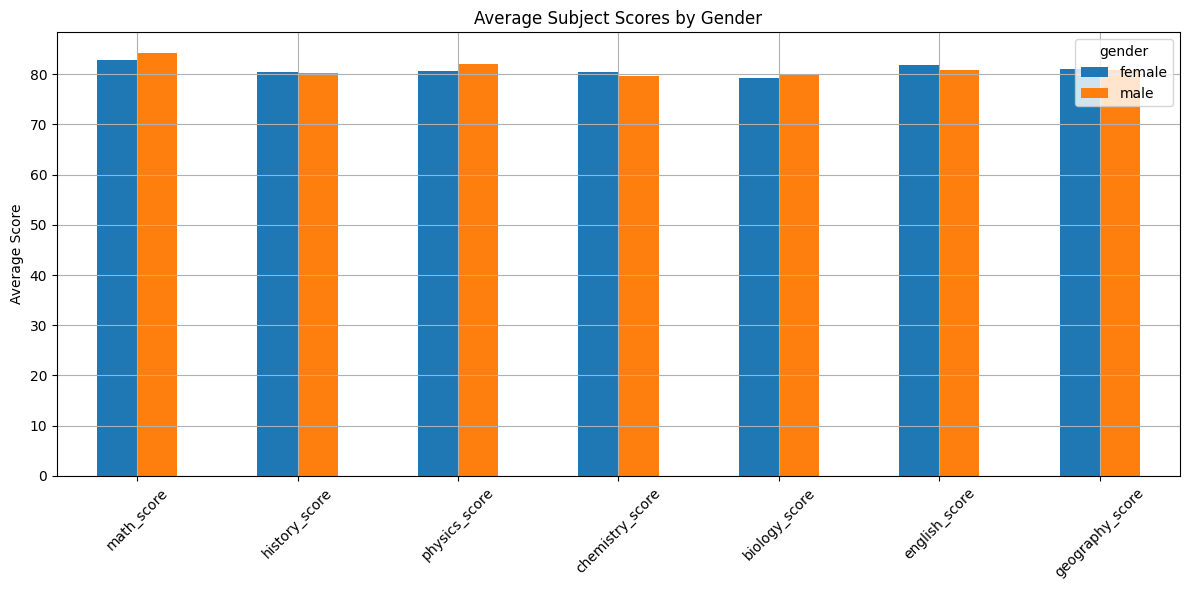

In [12]:
### STEP 4: Group-wise Performance

# Gender-based averages
gender_avg = df.groupby('gender')[score_columns].mean()
print("\nAverage Scores by Gender:\n", gender_avg)

# Plot gender-based scores
gender_avg.T.plot(kind='bar', figsize=(12, 6))
plt.title("Average Subject Scores by Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

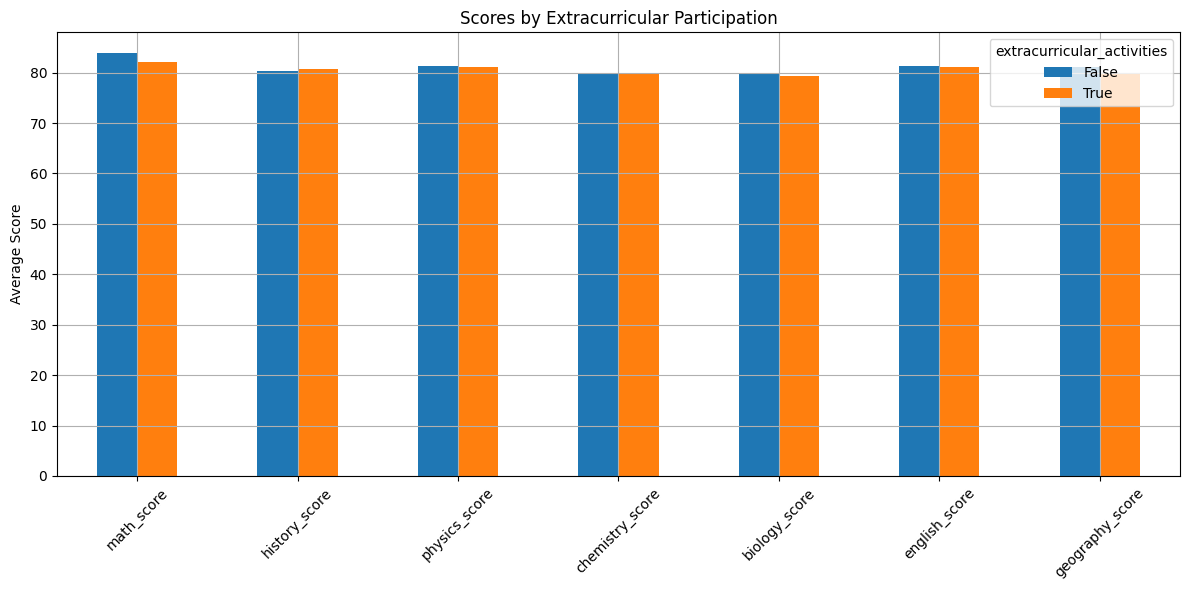

In [13]:
# Extracurricular vs Scores
extra_avg = df.groupby('extracurricular_activities')[score_columns].mean()
extra_avg.T.plot(kind='bar', figsize=(12, 6))
plt.title("Scores by Extracurricular Participation")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

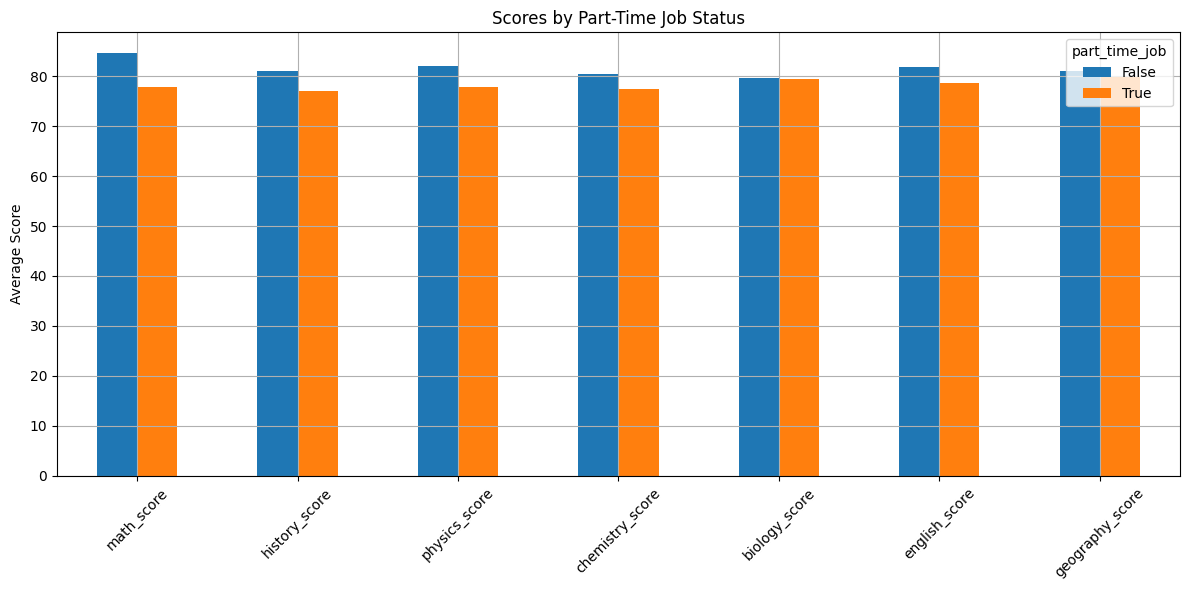

In [14]:
# Part-time job vs Scores
job_avg = df.groupby('part_time_job')[score_columns].mean()
job_avg.T.plot(kind='bar', figsize=(12, 6))
plt.title("Scores by Part-Time Job Status")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
### STEP 5: Top & Bottom Performers
# Add total and average score columns
df['total_score'] = df[score_columns].sum(axis=1)
df['average_score'] = df['total_score'] / len(score_columns)

# Top 5 Students
print("\nTop 5 Students by Average Score:\n",
      df[['first_name', 'last_name', 'average_score']].sort_values(by='average_score', ascending=False).head())

# Bottom 5 Students
print("\nBottom 5 Students by Average Score:\n",
      df[['first_name', 'last_name', 'average_score']].sort_values(by='average_score').head())



Top 5 Students by Average Score:
      first_name  last_name  average_score
796        Lisa   Mitchell      96.142857
779        Todd     Howard      95.857143
1573      Paula  Hernandez      95.857143
1419       Mary     Arnold      95.714286
551        Paul    Shaffer      95.714286

Bottom 5 Students by Average Score:
      first_name last_name  average_score
1965   Jennifer   Leblanc      59.142857
1661     Thomas     Scott      59.142857
906      Alicia   Beltran      61.428571
527     Deborah     Rojas      63.142857
819      Steven   Alvarez      63.285714


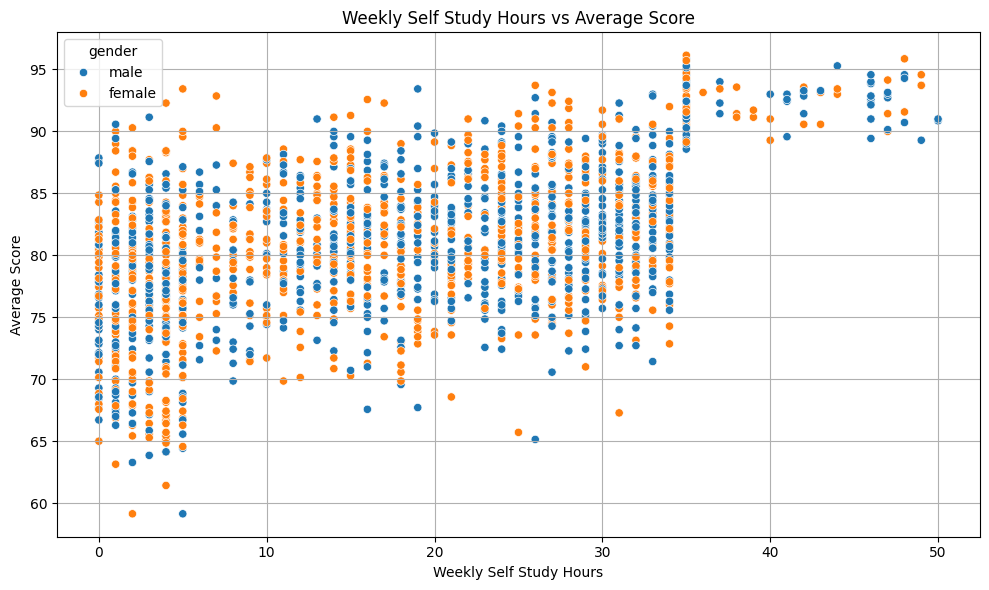

In [16]:
### STEP 6: Self-Study vs Performance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weekly_self_study_hours', y='average_score', hue='gender')
plt.title("Weekly Self Study Hours vs Average Score")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Average Score")
plt.grid(True)
plt.tight_layout()
plt.show()


Number of Students in Each Performance Cluster:
Low Performers (Cluster 0): 525 students
Medium Performers (Cluster 1): 756 students
High Performers (Cluster 2): 719 students


<ipython-input-8-f32b9c83e5ed>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='performance_cluster', data=df, palette='viridis')


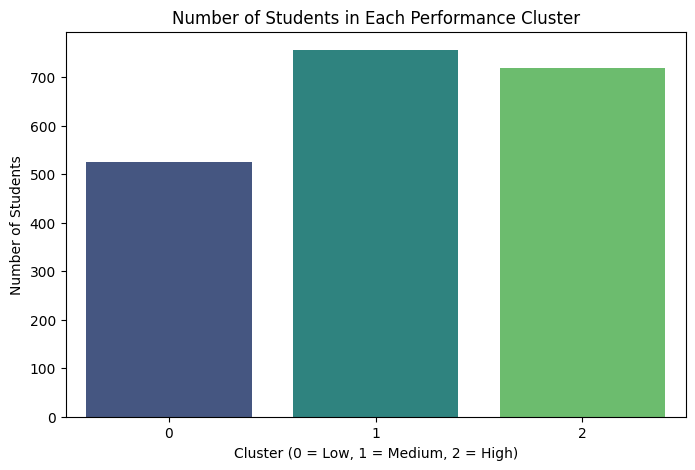

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize the score data
X = df[score_columns]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans Clustering (3 clusters: low, medium, high performance)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['performance_cluster'] = kmeans.fit_predict(X_scaled)

# Optional: Sort cluster labels by average performance for interpretability
cluster_means = df.groupby('performance_cluster')['average_score'].mean().sort_values()
label_map = {old: new for new, old in enumerate(cluster_means.index)}
df['performance_cluster'] = df['performance_cluster'].map(label_map)

# Display counts of students in each cluster
cluster_counts = df['performance_cluster'].value_counts().sort_index()
print("\nNumber of Students in Each Performance Cluster:")
for i, count in cluster_counts.items():
    label = ['Low', 'Medium', 'High'][i]
    print(f"{label} Performers (Cluster {i}): {count} students")

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.countplot(x='performance_cluster', data=df, palette='viridis')
plt.title("Number of Students in Each Performance Cluster")
plt.xlabel("Cluster (0 = Low, 1 = Medium, 2 = High)")
plt.ylabel("Number of Students")
plt.show()


In [9]:
# Define subject score columns
score_columns = ['math_score', 'history_score', 'physics_score',
                 'chemistry_score', 'biology_score', 'english_score', 'geography_score']

# Calculate average score per subject across all students
subject_avg_scores = df[score_columns].mean().sort_values(ascending=False)

# Display ranked subjects
print("📊 Average Scores per Subject (High → Easy, Low → Difficult):\n")
print(subject_avg_scores)

# Optional: Show top 3 easiest and bottom 3 hardest subjects
print("\n✅ Subjects Students Find Easiest:\n", subject_avg_scores.head(3))
print("\n⚠️ Subjects Students Find Most Difficult (Consider Extra Classes):\n", subject_avg_scores.tail(3))


📊 Average Scores per Subject (High → Easy, Low → Difficult):

math_score         83.4520
physics_score      81.3365
english_score      81.2775
geography_score    80.8880
history_score      80.3320
chemistry_score    79.9950
biology_score      79.5815
dtype: float64

✅ Subjects Students Find Easiest:
 math_score       83.4520
physics_score    81.3365
english_score    81.2775
dtype: float64

⚠️ Subjects Students Find Most Difficult (Consider Extra Classes):
 history_score      80.3320
chemistry_score    79.9950
biology_score      79.5815
dtype: float64
